# Experiment 4: Transfer Learning Using Pre-Trained Vision Models — Car vs Bike


## Part A — Dataset Preparation

In [1]:
print("Harish M K -24BAD031")

Harish M K -24BAD031


In [2]:
!pip install -q tensorflow


In [3]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


In [4]:
# Manual upload — select the Car vs Bike zip downloaded from Kaggle
# (e.g. the "Car vs Bike Classification Dataset" — works as long as it
# has Car/Bike subfolders)
uploaded = files.upload()
print("Files uploaded:", list(uploaded.keys()))


Saving archive (8).zip to archive (8).zip
Files uploaded: ['archive (8).zip']


In [5]:
# Filename must match the uploaded file exactly (Kaggle downloads are
# often named generically, e.g. "archive (5).zip")
zip_path = "archive (8).zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("car_bike_data")


In [6]:
# Kaggle zips don't always extract into a predictable folder structure,
# so this is checked before hardcoding a path below
for root, dirs, files_list in os.walk("car_bike_data"):
    print(root, "->", dirs, f"({len(files_list)} files)")


car_bike_data -> ['Car-Bike-Dataset'] (0 files)
car_bike_data/Car-Bike-Dataset -> ['Bike', 'Car'] (0 files)
car_bike_data/Car-Bike-Dataset/Bike -> [] (2000 files)
car_bike_data/Car-Bike-Dataset/Car -> [] (2000 files)


In [7]:
data_dir = "car_bike_data/Car-Bike-Dataset"
assert os.path.exists(data_dir), f"{data_dir} not found — check the folder structure above"


In [8]:
# Per-class image counts, mainly to catch class imbalance early
class_folders = os.listdir(data_dir)
total_count = 0

for folder in class_folders:
    folder_path = os.path.join(data_dir, folder)
    if os.path.isdir(folder_path):
        n = len(os.listdir(folder_path))
        print(folder, ":", n, "images")
        total_count += n

print("Total images:", total_count)
assert total_count > 0, "No images found — check the upload and extraction steps"


Bike : 2000 images
Car : 2000 images
Total images: 4000


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

In [10]:
IMG_SIZE = 224  # required input size for ResNet50
BATCH_SIZE = 32

In [11]:
# Data augmentation is applied only to the training images
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.3,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

# Validation images are only preprocessed, not augmented
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.3
)

# 70% Training data
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=42
)

# 30% held-out data
val_test_generator = val_datagen.flow_from_directory(
    data_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=42
)

print("Class indices:", train_generator.class_indices)

Found 2800 images belonging to 2 classes.
Found 1200 images belonging to 2 classes.
Class indices: {'Bike': 0, 'Car': 1}


In [12]:
# ---------------------------------------------------------
# Create a proper 70/15/15 train-validation-test split
# ---------------------------------------------------------

import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Get all held-out image paths
all_files = val_test_generator.filepaths

# Get class label for each image
all_labels = [
    os.path.basename(os.path.dirname(path))
    for path in all_files
]

# ---------------------------------------------------------
# Split 30% held-out data into:
# 15% validation + 15% test
# ---------------------------------------------------------

val_files, test_files, val_labels, test_labels = train_test_split(
    all_files,
    all_labels,
    test_size=0.50,
    stratify=all_labels,
    random_state=42
)

print("Train samples:", train_generator.samples)
print("Validation samples:", len(val_files))
print("Test samples:", len(test_files))

print("\nValidation classes:")
print(pd.Series(val_labels).value_counts())

print("\nTest classes:")
print(pd.Series(test_labels).value_counts())


# ---------------------------------------------------------
# Create generator for validation/test images
# ---------------------------------------------------------

def create_file_generator(file_paths, labels, batch_size=32):

    datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    )

    file_df = pd.DataFrame({
        "filename": file_paths,
        "class": labels
    })

    generator = datagen.flow_from_dataframe(
        file_df,
        x_col="filename",
        y_col="class",
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=batch_size,
        class_mode="binary",
        shuffle=False,
        classes=["Bike", "Car"]
    )

    return generator


# ---------------------------------------------------------
# Create separate validation and test generators
# ---------------------------------------------------------

val_generator = create_file_generator(
    val_files,
    val_labels,
    BATCH_SIZE
)

test_generator = create_file_generator(
    test_files,
    test_labels,
    BATCH_SIZE
)

print("\nGenerators created successfully.")
print("Validation generator:", val_generator.samples, "images")
print("Test generator:", test_generator.samples, "images")

Train samples: 2800
Validation samples: 600
Test samples: 600

Validation classes:
Car     300
Bike    300
Name: count, dtype: int64

Test classes:
Car     300
Bike    300
Name: count, dtype: int64
Found 600 validated image filenames belonging to 2 classes.
Found 600 validated image filenames belonging to 2 classes.

Generators created successfully.
Validation generator: 600 images
Test generator: 600 images


## Part B — Implementing Transfer Learning

In [13]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [14]:
# include_top=False drops ResNet50's original 1000-class ImageNet head,
# since it will be replaced with a head sized for our 2 classes
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [15]:
# Freezing retains the pre-trained ImageNet features; only the new
# layers added below will be updated during training
for layer in base_model.layers:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print("Trainable layers in base model:", trainable_count)


Trainable layers in base model: 0


In [16]:
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output_layer = Dense(1, activation="sigmoid")(x)

model = Model(
    inputs=base_model.input,
    outputs=output_layer
)


In [17]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_resnet50_car_bike.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

In [18]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",  # standard for 2-class, single-unit sigmoid output
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Part C — Model Training and Performance Evaluation

In [19]:


EPOCHS = 10

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/10
16/88 ━━━━━━━━━━━━━━━━━━━━ 29s 404ms/step - accuracy: 0.8634 - loss: 0.2654

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


88/88 ━━━━━━━━━━━━━━━━━━━━ 81s 658ms/step - accuracy: 0.9743 - loss: 0.0675 - val_accuracy: 0.9783 - val_loss: 0.0745 - learning_rate: 0.0010
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 52s 594ms/step - accuracy: 0.9854 - loss: 0.0493 - val_accuracy: 0.9850 - val_loss: 0.0509 - learning_rate: 0.0010
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 45s 515ms/step - accuracy: 0.9925 - loss: 0.0184 - val_accuracy: 0.9917 - val_loss: 0.0541 - learning_rate: 0.0010
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 43s 494ms/step - accuracy: 0.9939 - loss: 0.0178 - val_accuracy: 0.9833 - val_loss: 0.0602 - learning_rate: 0.0010
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 44s 503ms/step - accuracy: 0.9961 - loss: 0.0125 - val_accuracy: 0.9883 - val_loss: 0.0573 - learning_rate: 2.0000e-04


In [22]:
# ---------------------------------------------------------
# Print Initial Training Results
# ---------------------------------------------------------

print("Initial Transfer Learning Results")
print("----------------------------------")

num_initial_epochs = len(history.history["accuracy"])

for i in range(num_initial_epochs):
    print(
        f"Epoch {i+1} - "
        f"train_acc: {history.history['accuracy'][i]:.4f}, "
        f"val_acc: {history.history['val_accuracy'][i]:.4f}, "
        f"train_loss: {history.history['loss'][i]:.4f}, "
        f"val_loss: {history.history['val_loss'][i]:.4f}"
    )


# ---------------------------------------------------------
# Fine-Tuning ResNet-50
# ---------------------------------------------------------

# Freeze all ResNet-50 layers
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze the last 20 layers
for layer in base_model.layers[-20:]:
    layer.trainable = True

print(
    "\nTrainable layers:",
    sum(1 for layer in base_model.layers if layer.trainable)
)


# Recompile with a smaller learning rate
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# Fine-tune for 5 additional epochs
fine_tune_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)


# ---------------------------------------------------------
# Print Fine-Tuning Results
# ---------------------------------------------------------

print("\nFine-Tuning Results")
print("-------------------")

num_fine_tune_epochs = len(
    fine_tune_history.history["accuracy"]
)

for i in range(num_fine_tune_epochs):
    print(
        f"Fine-Tune Epoch {i+1} - "
        f"train_acc: {fine_tune_history.history['accuracy'][i]:.4f}, "
        f"val_acc: {fine_tune_history.history['val_accuracy'][i]:.4f}, "
        f"train_loss: {fine_tune_history.history['loss'][i]:.4f}, "
        f"val_loss: {fine_tune_history.history['val_loss'][i]:.4f}"
    )

Initial Transfer Learning Results
----------------------------------
Epoch 1 - train_acc: 0.9743, val_acc: 0.9783, train_loss: 0.0675, val_loss: 0.0745
Epoch 2 - train_acc: 0.9854, val_acc: 0.9850, train_loss: 0.0493, val_loss: 0.0509
Epoch 3 - train_acc: 0.9925, val_acc: 0.9917, train_loss: 0.0184, val_loss: 0.0541
Epoch 4 - train_acc: 0.9939, val_acc: 0.9833, train_loss: 0.0178, val_loss: 0.0602
Epoch 5 - train_acc: 0.9961, val_acc: 0.9883, train_loss: 0.0125, val_loss: 0.0573

Trainable layers: 20
Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 75s 631ms/step - accuracy: 0.9950 - loss: 0.0160 - val_accuracy: 0.9783 - val_loss: 0.2392 - learning_rate: 1.0000e-04
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 45s 506ms/step - accuracy: 0.9979 - loss: 0.0079 - val_accuracy: 0.9867 - val_loss: 0.1998 - learning_rate: 1.0000e-04
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 44s 498ms/step - accuracy: 0.9982 - loss: 0.0040 - val_accuracy: 0.9883 - val_loss: 0.1236 - learning_rate: 2.0000e-05

Fine-Tuning Results
-----

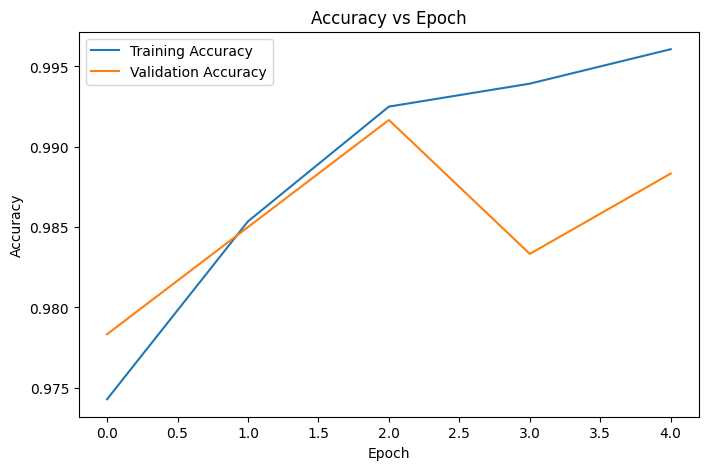

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()


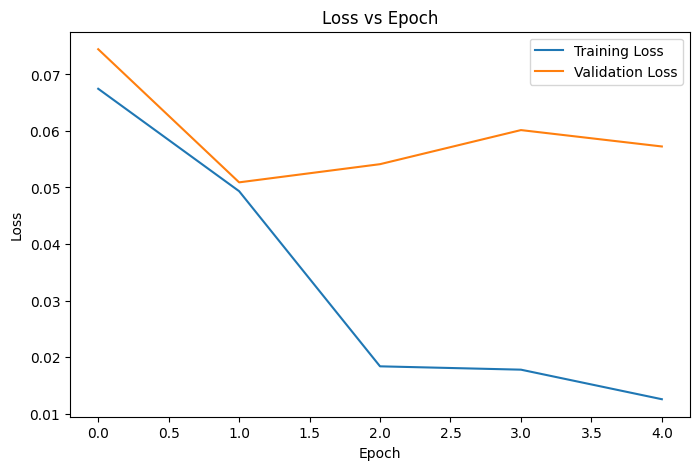

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Predictions on the separate 600-image test set
probabilities = model.predict(
    test_generator,
    verbose=0
).ravel()

predictions = (probabilities >= 0.5).astype(int)

true_labels = test_generator.classes

accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)
auc = roc_auc_score(true_labels, probabilities)

print("Final Test Performance")
print("----------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        true_labels,
        predictions,
        target_names=["Bike", "Car"]
    )
)

Final Test Performance
----------------------
Accuracy : 0.9783
Precision: 0.9614
Recall   : 0.9967
F1-Score : 0.9787
AUC      : 0.9913

Classification Report:
              precision    recall  f1-score   support

        Bike       1.00      0.96      0.98       300
         Car       0.96      1.00      0.98       300

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600



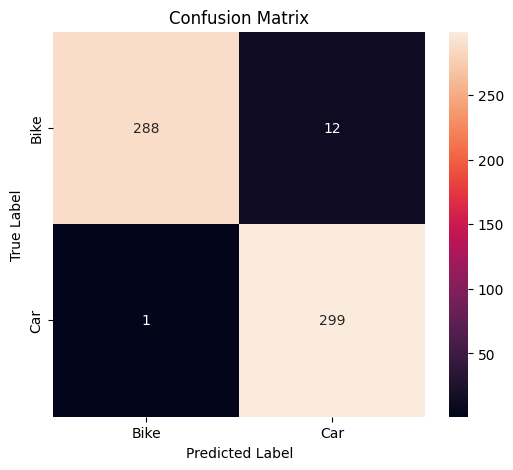

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Bike", "Car"],
    yticklabels=["Bike", "Car"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [27]:
test_loss, test_acc = model.evaluate(
    test_generator,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

14/19 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9841 - loss: 0.3382

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.9783 - loss: 0.3456
Test Loss: 0.34562110900878906
Test Accuracy: 0.9783333539962769
Test Accuracy: 97.83%


## Part D — Using Hugging Face Pre-Trained Models

In [28]:
!pip install -q transformers


In [29]:
from transformers import pipeline

# ViT trained on full 1000-class ImageNet — not fine-tuned on cars/bikes,
# which is the point of the comparison
hf_model = pipeline("image-classification", model="google/vit-base-patch16-224")


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

In [31]:
import random

# Separate validation images by class
bike_files = [
    path for path, label in zip(val_files, val_labels)
    if label == "Bike"
]

car_files = [
    path for path, label in zip(val_files, val_labels)
    if label == "Car"
]

# Select 3 Bike + 3 Car images
sample_imgs = (
    random.sample(bike_files, 3) +
    random.sample(car_files, 3)
)

print("Selected 3 Bike images and 3 Car images.")

Selected 3 Bike images and 3 Car images.


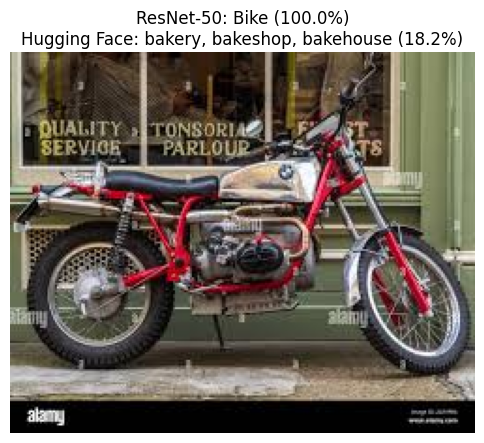

Image: car_bike_data/Car-Bike-Dataset/Bike/Bike (1388).jpeg
ResNet-50 prediction: Bike (1.000)
Hugging Face prediction: bakery, bakeshop, bakehouse (0.182)
------------------------------------------------------------


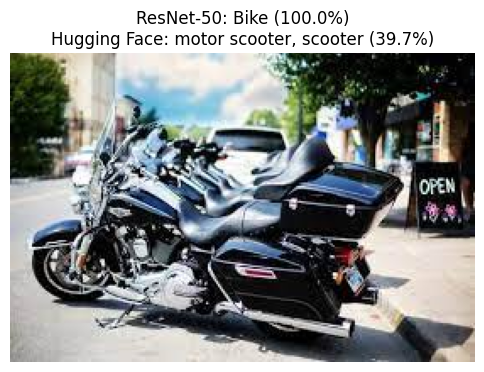

Image: car_bike_data/Car-Bike-Dataset/Bike/Bike (1072).jpeg
ResNet-50 prediction: Bike (1.000)
Hugging Face prediction: motor scooter, scooter (0.397)
------------------------------------------------------------


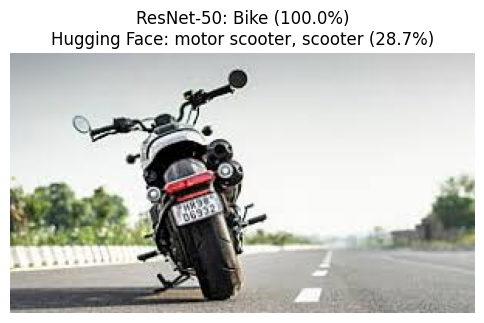

Image: car_bike_data/Car-Bike-Dataset/Bike/Bike (1079).jpeg
ResNet-50 prediction: Bike (1.000)
Hugging Face prediction: motor scooter, scooter (0.287)
------------------------------------------------------------


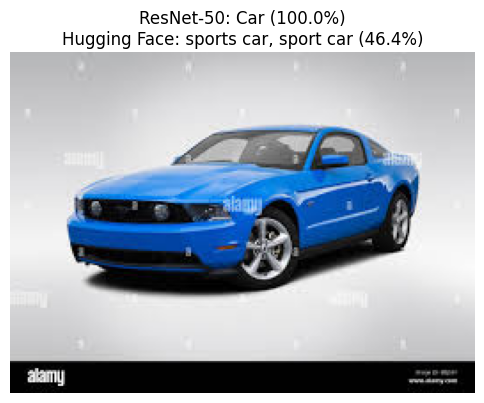

Image: car_bike_data/Car-Bike-Dataset/Car/Car (1520).jpeg
ResNet-50 prediction: Car (1.000)
Hugging Face prediction: sports car, sport car (0.464)
------------------------------------------------------------


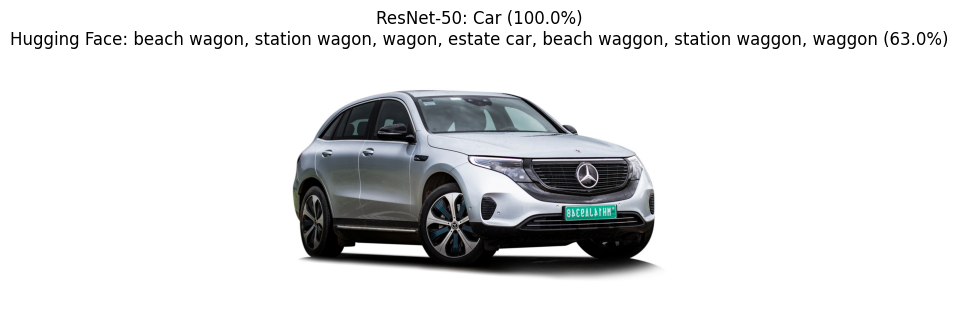

Image: car_bike_data/Car-Bike-Dataset/Car/Car (1008).jpeg
ResNet-50 prediction: Car (1.000)
Hugging Face prediction: beach wagon, station wagon, wagon, estate car, beach waggon, station waggon, waggon (0.630)
------------------------------------------------------------


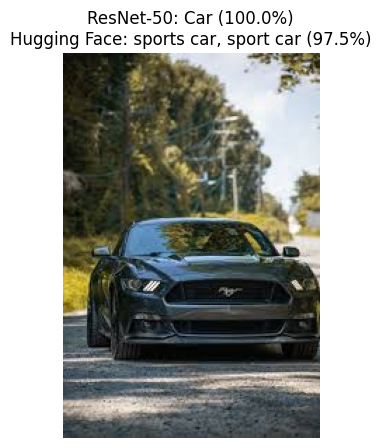

Image: car_bike_data/Car-Bike-Dataset/Car/Car (1431).jpeg
ResNet-50 prediction: Car (1.000)
Hugging Face prediction: sports car, sport car (0.975)
------------------------------------------------------------


In [32]:
import matplotlib.pyplot as plt
from PIL import Image

class_names = list(train_generator.class_indices.keys())

for img_path in sample_imgs:

    # Original image for display
    original_img = Image.open(img_path).convert("RGB")

    # Resize for ResNet-50
    im = original_img.resize((IMG_SIZE, IMG_SIZE))

    # Preprocess image
    im_array = preprocess_input(np.array(im))
    im_array = np.expand_dims(im_array, axis=0)

    # ResNet-50 prediction
    my_pred_prob = model.predict(
        im_array,
        verbose=0
    )[0][0]

    if my_pred_prob >= 0.5:
        my_class = class_names[1]
        my_confidence = my_pred_prob
    else:
        my_class = class_names[0]
        my_confidence = 1 - my_pred_prob

    # Hugging Face prediction
    hf_pred = hf_model(original_img)

    hf_label = hf_pred[0]["label"]
    hf_confidence = hf_pred[0]["score"]

    # Display image
    plt.figure(figsize=(6, 5))
    plt.imshow(original_img)
    plt.axis("off")

    plt.title(
        f"ResNet-50: {my_class} ({my_confidence:.1%})\n"
        f"Hugging Face: {hf_label} ({hf_confidence:.1%})"
    )

    plt.show()

    print("Image:", img_path)
    print(
        f"ResNet-50 prediction: "
        f"{my_class} ({my_confidence:.3f})"
    )
    print(
        f"Hugging Face prediction: "
        f"{hf_label} ({hf_confidence:.3f})"
    )
    print("-" * 60)

**Observations:** The fine-tuned ResNet50 model always predicts either Car or Bike, since that's what it was trained on. The Hugging Face ViT model, trained on the full 1000-class ImageNet set, often returns a more specific label (e.g. \"sports car\", \"moped\", or \"mountain bike\") rather than the generic class, since it was never fine-tuned on this dataset — illustrating why fine-tuning on target data matters for task-specific output.
